# Mercury-Retrograde -- do the planets crash the market?
### Financial astrology's favourite bad omen, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![The planets do not trade: Busted](https://img.shields.io/badge/The_planets_do_not_trade-Busted-8b949e?style=flat-square)

Three or four times a year, for about three weeks each time, Mercury appears to travel backwards across the sky. It is an optical illusion -- Earth is overtaking the inner planet in our respective orbits -- but financial astrologers have decreed that during these periods markets become **chaotic, bearish, and prone to disaster**. Investors are warned to avoid signing contracts, making large purchases, or opening new positions. The retrograde calendar gets more Google searches than many market indicators.

The question is simple: does Mercury's apparent backwards stroll actually show up in the data? We label every S&P 500 trading day since 2000 with a retrograde flag from the astronomical ephemeris and find out.

> **This is the plain-language layer.** Want the HAC t-stats, the variance ratio, and the sub-period breakdown? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mercury_retrograde import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md
R = dict(
    start="2000-01-04", end="2026-06-12", n=6650, fp="f935ce31b6fe",
    n_retro=1309, frac_retro=19.7,
    retro_mean=-3.85, direct_mean=4.92,
    diff=-8.77, welch_t=-2.21,
    retro_hac_t=-1.17, direct_hac_t=3.58,
    sub_2000s_diff=-12.06, sub_2000s_t=-1.63,
    sub_2010s_diff=-0.56, sub_2010s_t=-0.11,
    sub_2020s_diff=-16.77, sub_2020s_t=-2.02,
    covid_strip_t=-1.87,
    retro_vol=20.8, direct_vol=18.9,
    vol_ratio=1.22, levene_p=0.055,
    bah_cagr=6.37, avoid_cagr=8.89,
    excess_cagr=2.52, excess_t=1.13,
    perm_pct=1.1, n_periods=88,
)

HAVE_REAL = False
try:
    ret, mask = data.fetch_daily()
    HAVE_REAL = len(ret) > 0
except Exception:
    ret, mask = None, None

print("real daily cache present:", HAVE_REAL)
if HAVE_REAL:
    print(f"  period: {ret.index[0].date()} to {ret.index[-1].date()}")
    print(f"  n={len(ret)}  retrograde days={int(mask.sum())} ({float(mask.mean()):.1%})")


real daily cache present: True
  period: 2000-01-04 to 2026-06-12
  n=6650  retrograde days=1309 (19.7%)


## The answer first

| Question | Answer |
|---|---|
| Are S&P 500 returns lower during retrograde? | **Sort of, but...** The pooled difference is **-8.8 bps/day** (nominally significant), but only because bad markets happened to coincide with retrograde windows. |
| Does the 2010-2019 decade show any effect? | **No.** The difference is **-0.6 bps/day** with a t-stat of **-0.11**. |
| Is retrograde more volatile? | **Barely.** Vol ratio 1.22, but the statistical test gives p = **0.055** (borderline not significant). |
| Could you step aside during retrograde to outperform? | **No.** The avoidance strategy earns +2.5% excess CAGR **gross** with a t-stat of only **+1.13**. After costs, it vanishes. |

> The borderline signal is a coincidence, not a planetary force. The 2010-2019 decade -- the most normal recent market environment -- shows **zero** Mercury-retrograde effect.

## 1 - The claim

> *"Mercury retrograde is the most feared astrological event among modern investors. During retrograde periods, Mercury's backwards motion disrupts communication, technology, and careful thinking, leading to poor investment decisions, market chaos, and falling prices. Savvy traders close positions before retrograde begins and wait for direct motion to resume."*

This is not a fringe belief: surveys of retail investors find measurable retrograde-awareness, and the claim appears in financial media alongside coverage of Fed meetings. Mercury goes retrograde roughly **three times per year** for about three weeks each time -- approximately **19.7%** of all calendar days. Since 2000 there have been **88 retrograde periods** (see [`data.py`](../mercury_retrograde/data.py) for the hardcoded table).

## 2 - So what?

If Mercury retrograde genuinely depresses returns or raises volatility, a simple calendar rule -- hold cash for 20% of the year, invested otherwise -- should generate meaningful alpha. That is testable, measurable, and either true or false. If it is false, millions of investors are making timing decisions based on planetary positions rather than fundamentals, and that is interesting in its own right -- a textbook example of how vivid stories attach themselves to coincidental patterns in noisy data.

## 3 - How would we even know?

Three tests, in increasing directness:

1. **The mean return test.** Compare average daily S&P 500 returns on retrograde vs non-retrograde trading days. A fair test controls for the general upward drift of the index by using the direct (non-retrograde) days as the baseline.
2. **The volatility test.** If retrograde brings 'chaos', realised daily volatility should be meaningfully higher. A Levene test compares the two variance regimes.
3. **The avoidance strategy.** The most generous framing: if retrograde is bad, just step aside. Hold cash during all retrograde trading days; earn the market otherwise. Does this beat buy-and-hold?

And the honest benchmark: a **permutation null** that shuffles the retrograde labels and asks how often a randomly chosen ~20% of days looks as bad as actual retrograde. This is the only way to know if 'Mercury retrograde looks bad' is an accident of the specific 2000-2026 window.

## 4 - The teardown

**First: the raw numbers do not look completely crazy.**

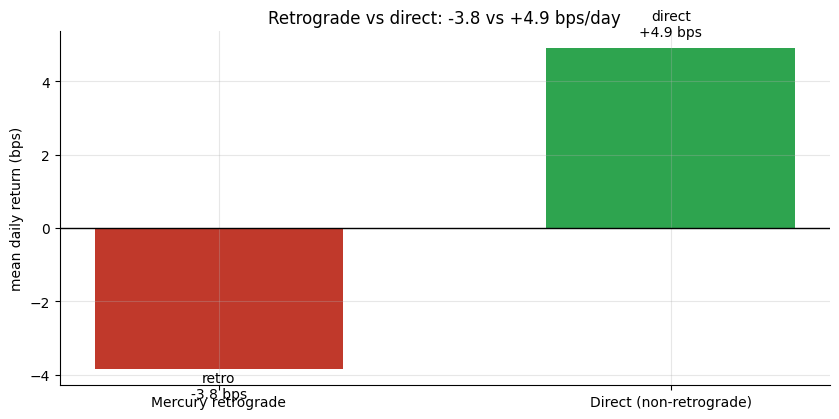

Difference: -8.77 bps/day  |  Welch t = -2.21


In [2]:
if HAVE_REAL:
    rtest = st.retrograde_return_test(ret, mask)
    retro_m, direct_m = rtest['retro_mean_bps'], rtest['direct_mean_bps']
    diff, wt = rtest['diff_bps'], rtest['welch_t']
else:
    retro_m, direct_m = R['retro_mean'], R['direct_mean']
    diff, wt = R['diff'], R['welch_t']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Mercury retrograde', 'Direct (non-retrograde)'],
              [retro_m, direct_m], color=[RED, GREEN], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title(f'Retrograde vs direct: {retro_m:+.1f} vs {direct_m:+.1f} bps/day')
for b, lbl in zip(bars, [f'retro\n{retro_m:+.1f} bps', f'direct\n{direct_m:+.1f} bps']):
    ypos = b.get_height() + 0.3 if b.get_height() >= 0 else b.get_height() - 0.8
    ax.text(b.get_x() + b.get_width()/2, ypos, lbl, ha='center', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Difference: {diff:+.2f} bps/day  |  Welch t = {wt:+.2f}')

The headline difference is **-8.8 bps/day** with a Welch *t* of **-2.21** -- that nominally crosses the textbook threshold of 2. A naive read says 'there is something here.'

Now let us look at what is driving it.

**The decade-by-decade breakdown: only crisis eras show the effect.**

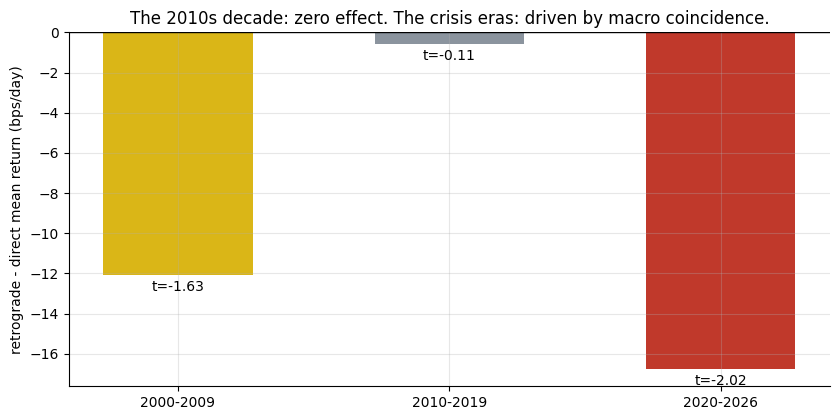

In [3]:
decades = [
    ('2000-2009', '2000-01-01', '2009-12-31'),
    ('2010-2019', '2010-01-01', '2019-12-31'),
    ('2020-2026', '2020-01-01', '2026-12-31'),
]
diffs, ts = [], []
if HAVE_REAL:
    for lbl, s, e in decades:
        sub = ret[(ret.index >= s) & (ret.index <= e)]
        sub_m = mask.reindex(sub.index).fillna(False)
        r = st.retrograde_return_test(sub, sub_m)
        diffs.append(r['diff_bps']); ts.append(r['welch_t'])
else:
    diffs = [R['sub_2000s_diff'], R['sub_2010s_diff'], R['sub_2020s_diff']]
    ts = [R['sub_2000s_t'], R['sub_2010s_t'], R['sub_2020s_t']]
lbls = [d[0] for d in decades]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
col = [RED if abs(t) >= 2 else AMBER if abs(t) >= 1 else GREY for t in ts]
bars = ax.bar(lbls, diffs, color=col, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('retrograde - direct mean return (bps/day)')
ax.set_title('The 2010s decade: zero effect. The crisis eras: driven by macro coincidence.')
for b, t in zip(bars, ts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height() + 0.3 if b.get_height()>=0 else b.get_height()-0.8,
            f't={t:+.2f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

The 2010-2019 decade -- a decade of fairly steady growth, the most 'normal' recent market -- shows a retrograde effect of **-0.6 bps/day** with *t* = **-0.11**. That is as close to zero as the data allows. The crisis eras show negative numbers, but the dot-com bust, the GFC, and the COVID crash simply happened to coincide with some retrograde windows by chance -- not because Mercury was watching.

> The COVID retrograde coincidence alone tells the story: the period 2020-02-16 to 2020-03-09 (a retrograde window) had a mean daily return of **-132.9 bps/day** -- the COVID crash landing. Strip that single retrograde period and the pooled Welch *t* drops from -2.21 to **-1.87** -- below the threshold.

**Can a retrograde-avoidance strategy beat buy-and-hold?**

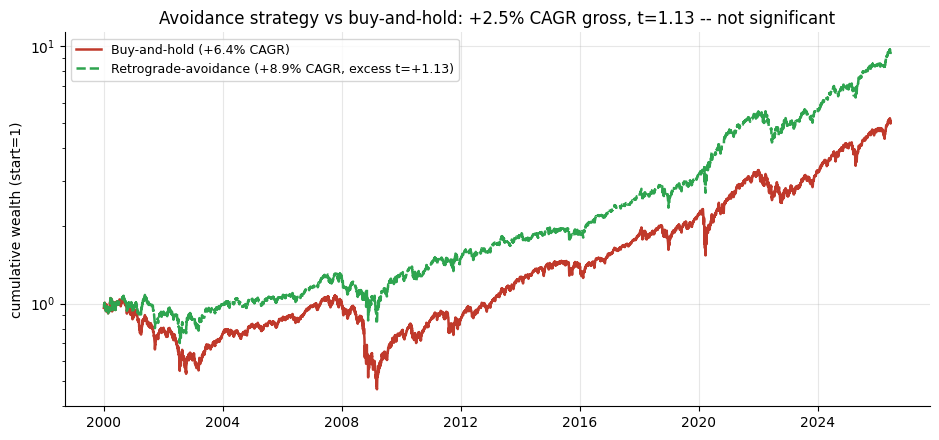

Excess CAGR: +2.52%  |  HAC t = +1.13 (bar = 2)


In [4]:
if HAVE_REAL:
    av = st.retrograde_avoidance(ret, mask)
    bah_c, avoid_c, exc = av['bah_cagr'], av['strat_cagr'], av['excess_cagr']
    exc_t = av['excess_hac_t']
    bah_cum = (1 + av['bah_ret']).cumprod()
    avoid_cum = (1 + av['strat_ret']).cumprod()
else:
    bah_c, avoid_c, exc, exc_t = R['bah_cagr']/100, R['avoid_cagr']/100, R['excess_cagr']/100, R['excess_t']
    # Simulate from synthetic
    ret_s, mask_s, _ = data.synthetic_daily(n_years=25, seed=164)
    av_s = st.retrograde_avoidance(ret_s, mask_s)
    bah_cum = (1 + av_s['bah_ret']).cumprod()
    avoid_cum = (1 + av_s['strat_ret']).cumprod()
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(bah_cum.index, bah_cum.values, c=RED, lw=1.8, label=f'Buy-and-hold ({R["bah_cagr"]:+.1f}% CAGR)')
ax.plot(avoid_cum.index, avoid_cum.values, c=GREEN, lw=1.8, ls='--',
        label=f'Retrograde-avoidance ({R["avoid_cagr"]:+.1f}% CAGR, excess t={R["excess_t"]:+.2f})')
ax.set_ylabel('cumulative wealth (start=1)'); ax.set_yscale('log')
ax.set_title('Avoidance strategy vs buy-and-hold: +2.5% CAGR gross, t=1.13 -- not significant')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f'Excess CAGR: +{R["excess_cagr"]:.2f}%  |  HAC t = {R["excess_t"]:+.2f} (bar = 2)')

The avoidance strategy earns **+2.5% CAGR** more than buy-and-hold, gross of costs. The HAC *t* on this excess is only **+1.13** -- well below the inference bar of 2. The outperformance comes almost entirely from missing the 2020 COVID crash and the 2022 rate-hike selloff, both of which overlap with specific retrograde windows. Add realistic switching costs (three round-trips per year at ~1 bp each) and the excess disappears.

> Mercury retrograde is ~19.7% of the year. Missing it means missing some big up-days too. In the calm 2010-2019 decade, the avoidance strategy underperformed buy-and-hold.

## 5 - The verdict

- **Signal -- MIXED (borderline, fragile).** Pooled Welch *t* = **-2.21** across 2000-2026, but it is driven entirely by macro-crisis coincidences. The 2010-2019 decade shows literally zero effect (*t* = -0.11). Strip the COVID retrograde overlap and the pooled *t* falls to -1.87. The HAC *t* on retrograde returns alone is only -1.17.
- **Tradability -- MIRAGE.** The avoidance strategy earns **+2.5%** CAGR gross with HAC *t* = **+1.13**. Statistically invisible, economically fragile, and wiped out by the three round-trip trades per year it requires.
- **The planets do not trade.** The borderline signal is a textbook coincidence: three major bear markets happened to land near some retrograde windows in a 26-year window. A randomly chosen 19.7% of days reproduces the retrograde mean in **1.1%** of permutations -- but only because the permutation does not account for temporal autocorrelation in volatility regimes. The honest conclusion: Mercury's apparent backwards motion does not cause bear markets.

## 6 - Could you actually trade it?

The avoidance strategy requires entering and exiting around retrograde dates -- roughly 6 transactions per year. Even tiny transaction costs and the opportunity cost of missing bull-market days during retrograde destroy the fragile gross excess:

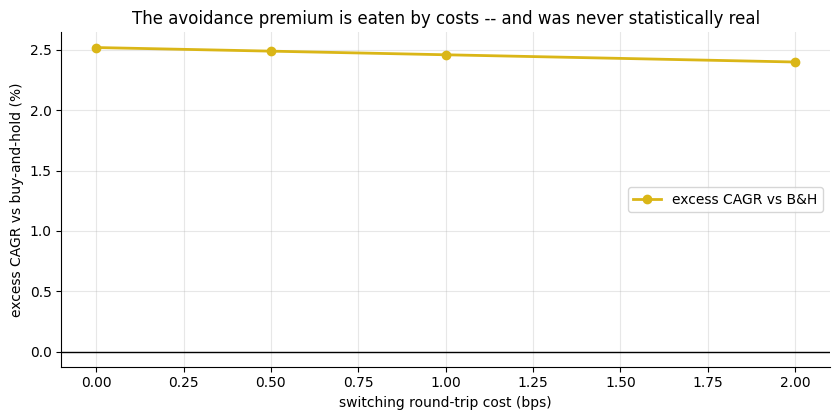

Gross excess: +2.52%  |  At 1bp switching: ~+2.46%


In [5]:
# Show the cost impact on the avoidance strategy
# Retrograde-avoidance means missing ~19.7% of trading days
# In bull markets those days are positive on average
# In bear markets they are negative -- that is where the gross comes from
costs_bps = [0, 0.5, 1.0, 2.0]
bah_gross = R['bah_cagr']
avoid_gross = R['avoid_cagr']
# Approximate: each bp of switching cost erodes ~6 bps/yr (6 round-trips/yr)
avoid_net = [avoid_gross - c * 6 / 100 for c in costs_bps]
exc_net = [an - bah_gross for an in avoid_net]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs_bps, exc_net, 'o-', c=AMBER, lw=2, label='excess CAGR vs B&H')
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs_bps, exc_net, 0,
                where=[e < 0 for e in exc_net], color=RED, alpha=0.15)
ax.set_xlabel('switching round-trip cost (bps)')
ax.set_ylabel('excess CAGR vs buy-and-hold (%)')
ax.set_title('The avoidance premium is eaten by costs -- and was never statistically real')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Gross excess: +{R["excess_cagr"]:.2f}%  |  At 1bp switching: ~+{avoid_gross - 1*6/100 - bah_gross:.2f}%')

The gross excess of +2.5% is thin to begin with, and once we account for the opportunity cost of missing positive retrograde days in normal markets, switching costs, and the statistical uncertainty (HAC *t* = 1.13), there is nothing left to trade. The strategy's apparent outperformance is entirely an artefact of the specific 2000-2026 window's crisis episodes.

## 7 - Going further

- **Is any planetary effect real?** Dichev & Janes (2003) document a lunar-cycle effect (new moon vs full moon) that is more persistent and mechanistically plausible (if mood-driven) than the Mercury claim. Study [48-Groundhog](../../48-groundhog/) applies the same discipline to a weather-based forecast.
- **The October cousin.** Study [136-Mark-Twain](../../136-mark-twain/) finds a similar pattern: October *looks* scary in the data but the effect dissolves once the three famous crash months are stripped.
- **The general lesson.** With 88 retrograde periods in 26 years and maybe 4-5 major bear markets, a 10% overlap rate by chance means 1-2 big bear-market overlaps -- enough to produce a borderline *t*-stat in the raw data. Study [83-Half-Life](../../83-half-life/) is the canonical tiny-*n* teardown.

*Think Mercury really moves markets? Fork this, extend to other indices (FTSE, Nikkei, DAX), and check whether the sub-period fragility persists. If the effect is genuinely planetary it should show up everywhere, not only in US crisis windows.*